In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import matplotlib.pyplot as plt

sys.path.insert(0, "..")

from spec.enums import MainTableColumns as Cols
from spec.spec_definition import PS2Versions
import pandas as pd

In [78]:
from analytics.analytics_config import Granularity
from datasets.codeworkout import load_dataset, S19

# Select a dataset by setting the config variable
config = S19
dataset_name, dataset_semester = config.name.split('_')
dataset_root_dir = os.path.join('..', '..', 'sample_data', dataset_name, dataset_semester)
dataset = load_dataset(dataset_root_dir, config)

In [3]:
# Shorten some config variables for convenience
problem_id_col = config.primary_problem_grouping_column
timestamp_col = config.primary_timestamp_column

In [4]:
# TODO: Replace this with config files!

# from analytics.preprocessors.edwards import TimeStampToDateTimePreprocessor, ClassSubsetPreprocessor
# from analytics.preprocessors.codebench import YAMLLinkURLPreprocessor, CodeBenchAddParentEventIDs
# from analytics.preprocessors.codeworkout import CodeWorkoutExtractErrorTypesPreprocessor
# from analytics.ps2_dataset import SortPreprocessor, FilterPreprocessor
# from spec.enums import EventType

# data_config_path = None
# problem_id_col = None
# timestamp_col = None
# idle_gap = None
# break_gap = None
# main_table_preprocessors = []
# link_table_preprocessors = []
# submit_event = EventType.Submit
# grades_link_table = "Subject"
# grades_col = None
# start_time = None
# end_time = None
# early_percentage = None
# assignment_ids = None
# compile_error_type_column = Cols.CompileMessageType
# compile_event = EventType.Compile
# compile_error_event = EventType.CompileError
# output_suffix = ''

# falconcode_f21_config = {
#     "config_path": "sample_data_configs/falconcode.yaml",
#     "problem_id_col": Cols.ProblemID,
#     "timestamp_col": Cols.ServerTimestamp,
#     "idle_gap": 5 * 60,
#     "break_gap": 30 * 60,
#     "mt_preprocessing_steps": [
#         FilterPreprocessor(Cols.TermID, "Fall 2021"),
#     ],
#     "early_percentage": 0.25,
# }

# # Note: Only Fall has compilation data; spring has no Run.Program events!
# edwards_s19_config = {
#     "config_path": "sample_data_configs/edwards2019.yaml",
#     "problem_id_col": Cols.AssignmentID,
#     "timestamp_col": Cols.ClientTimestamp,
#     "idle_gap": 30,
#     "break_gap": 3 * 60,
#     "mt_preprocessing_steps": [
#         # Don't need this, since I've done and cached it
#         # AddErrors2021Preprocessor(),
#         TimeStampToDateTimePreprocessor(),
#         # Make sure this comes last so Fall is correct
#         ClassSubsetPreprocessor("Spring"),
#     ],
#     # Compile error info is stored in the Run.Program event itself
#     "compile_event": EventType.RunProgram,
#     "end_time": "2019-02-25 00:00:00",
#     "early_percentage": 0.23,
#     "assignment_ids": ["p4s", "p5s"],  # Only 2 assignments
#     "grades_col": "exam2",
#     "output_suffix": "-s19",
# }

# edwards_f19_config = edwards_s19_config.copy()
# edwards_f19_config["mt_preprocessing_steps"] = edwards_s19_config["mt_preprocessing_steps"].copy()
# edwards_f19_config["mt_preprocessing_steps"][-1] = ClassSubsetPreprocessor("Fall")
# edwards_f19_config["end_time"] = "2019-10-13 00:00:00"
# edwards_f19_config["assignment_ids"] = ["p4f", "p5f"]
# edwards_f19_config["early_percentage"] = 0.42
# edwards_f19_config["output_suffix"] = "-f19"

# edwards2021_config = {
#     "config_path": "sample_data_configs/edwards2021.yaml",
#     "problem_id_col": Cols.AssignmentID,
#     "timestamp_col": Cols.ClientTimestamp,
#     "idle_gap": 30,
#     "break_gap": 3 * 60,
#     "mt_preprocessing_steps": [
#         # Don't need this, since I've done and cached it
#         # AddErrors2021Preprocessor(),
#         TimeStampToDateTimePreprocessor(),
#     ],
#     # Compile error info is stored in the Run.Program event itself
#     "compile_event": EventType.RunProgram,
#     "end_time": "2022-01-01 00:00:00",
#     "early_percentage": 0.4,
#     "assignment_ids": ["Assign6", "Assign7"],  # Only 2 assignments
#     "grades_col": "FinalScore",
# }

# cwo_s19_config = {
#     "config_path": "sample_data_configs/cwo_s19.yaml",
#     "problem_id_col": Cols.ProblemID,
#     "timestamp_col": Cols.ServerTimestamp,
#     "idle_gap": 5 * 60,
#     "break_gap": 30 * 60,
#     "mt_preprocessing_steps": [
#         SortPreprocessor(),
#         CodeWorkoutExtractErrorTypesPreprocessor(),
#     ],
#     "submit_event": EventType.RunProgram,
#     "grades_col": "X-Grade",
#     "early_percentage": 0.33,
# }

# cwo_f19_config = {
#     "config_path": "sample_data_configs/cwo_f19.yaml",
#     "problem_id_col": Cols.ProblemID,
#     "timestamp_col": Cols.ServerTimestamp,
#     "idle_gap": 5 * 60,
#     "break_gap": 30 * 60,
#     "mt_preprocessing_steps": [
#         SortPreprocessor(),
#         CodeWorkoutExtractErrorTypesPreprocessor(),
#     ],
#     "submit_event": EventType.RunProgram,
#     "grades_col": "X-Grade",
#     "early_percentage": 0.25,
# }

# codebench2024_config = {
#     "config_path": "sample_data_configs/codebench2024.yaml",
#     "problem_id_col": Cols.ProblemID,
#     "timestamp_col": Cols.ServerTimestamp,
#     "idle_gap": 30,
#     "break_gap": 3 * 60,
#     "link_preprocessing_steps": [YAMLLinkURLPreprocessor(True)],
#     "mt_preprocessing_steps": [
#         CodeBenchAddParentEventIDs(),
#     ],
#     "grades_link_table": "CourseSubject",
#     "grades_col": "final-grade",
#     "start_time": "2024-09-01 00:00:00",
#     "early_percentage": 0.28,
#     "compile_error_type_col": "ProgramErrorOutput",
#     "compile_event": EventType.Submit,
#     "compile_error_event": EventType.RunTest,
# }

# # config = cwo_f19_config
# # config = cwo_s19_config
# # config = codebench2024_config
# # config = edwards2021_config
# # config = edwards_s19_config
# # config = edwards_f19_config
# config = falconcode_f21_config
# locals().update(config)

In [5]:
main_table = dataset.get_main_table()
main_table.head()

,Order,SubjectID,ToolInstances,ServerTimestamp,ServerTimezone,CourseID,CourseSectionID,AssignmentID,ProblemID,Attempt,CodeStateID,IsEventOrderingConsistent,EventType,Score,Compile.Result,CompileMessageType,CompileMessageData,EventID,ParentEventID,SourceLocation
0,0,f40a635828e2bffd0a598a7ed621fc93,Java 8; CodeWorkout,2019-03-20 19:34:25,0,CS 1,1,492.0,32,25,548938774dc948448b0bb51139bbcae3a3966ab8,True,Run.Program,1.0,NaN,None,NaN,32-84779,NaN,NaN
1,1,f40a635828e2bffd0a598a7ed621fc93,Java 8; CodeWorkout,2019-03-20 19:34:25,0,CS 1,1,492.0,32,25,548938774dc948448b0bb51139bbcae3a3966ab8,True,Compile,NaN,Success,None,NaN,32-84780,32-84779,NaN
2,2,f18374bf891c9af64c8570448824202d,Java 8; CodeWorkout,2019-03-20 21:02:00,0,CS 1,2,492.0,32,1,20dc599067ac07408b5636973fc6b8a37db9af32,True,Run.Program,1.0,NaN,None,NaN,32-84781,NaN,NaN
3,3,f18374bf891c9af64c8570448824202d,Java 8; CodeWorkout,2019-03-20 21:02:00,0,CS 1,2,492.0,32,1,20dc599067ac07408b5636973fc6b8a37db9af32,True,Compile,NaN,Success,None,NaN,32-84782,32-84781,NaN
4,4,4d230b683bf9840553ae57f4acc96e81,Java 8; CodeWorkout,2019-03-20 21:13:09,0,CS 1,1,492.0,32,1,23c57b36002c4d482df3d25f97778f74a2ed581a,True,Run.Program,0.0,NaN,None,NaN,32-84783,NaN,NaN


In [6]:
if config.start_time is not None:
    main_table = main_table[main_table[timestamp_col] >= config.start_time]
if config.end_time is not None:
    main_table = main_table[main_table[timestamp_col] <= config.end_time]

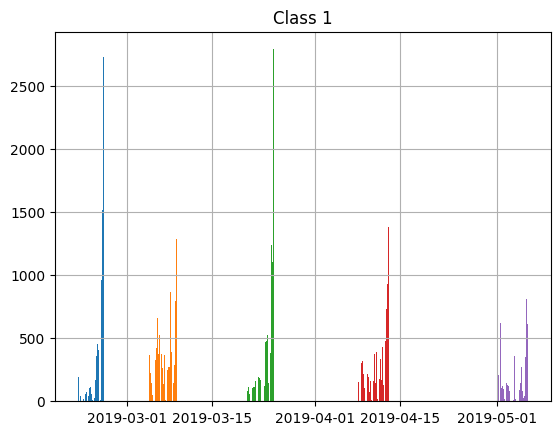

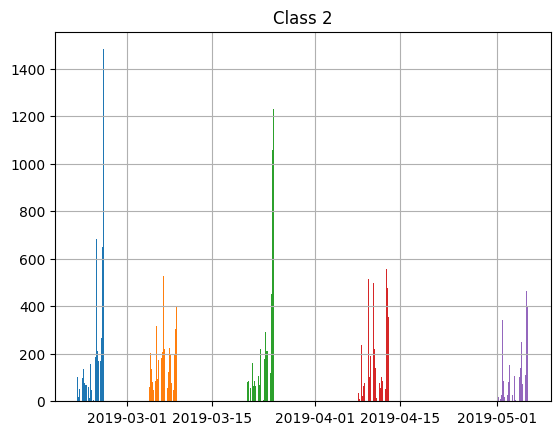

In [7]:
assignment_col = Cols.AssignmentID if Cols.AssignmentID in main_table.columns else problem_id_col
if Cols.CourseSectionID not in main_table.columns:
    main_table.groupby(assignment_col)[timestamp_col].hist(bins=100)
else:
    classes = main_table[Cols.CourseSectionID].unique()
    classes = classes[~pd.isna(classes)]
    for class_id in classes:
        subset = main_table[main_table[Cols.CourseSectionID] == class_id]
        hist = subset.groupby(assignment_col)[timestamp_col].hist(bins=100)
        plt.title(f"Class {class_id}")
        plt.show()

In [17]:
main_table.AssignmentID.unique()

array([492., 494., 439., 502., 487.])

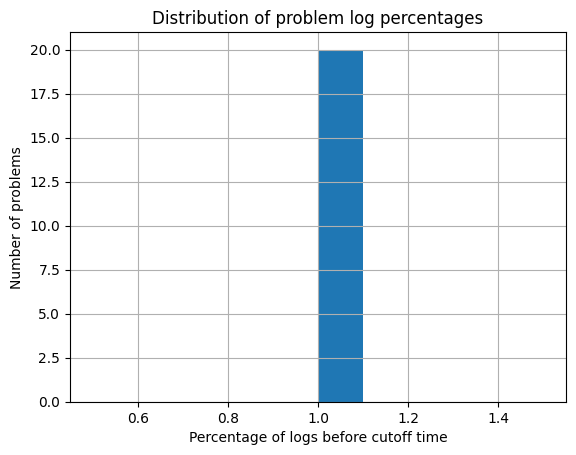

Removing partial problems: Index([], dtype='int64', name='ProblemID')
This removed 0.00% of data
Semester start 2019-02-20 17:40:39
Semester end 2019-05-06 03:58:44
Early cutoff time 2019-03-15 00:00:00
Early Assignment IDs: [439. 487.]
Early Problem IDs: [234  13  12 232 233   5 235  25 236  21   1 102   3  24 100  28 101  22
  17  20]
Total number of rows: 94876
Percent of logs:  47.068512179391774
Assignments: 2 / 5
Problems: 20 / 50


In [19]:
from analytics.preprocessors.early_cutoff import filter_before_time

data_subset = filter_before_time(main_table, config.early_time, timestamp_col, filter_problems=True, verbose=True)

In [ ]:
# Get data from early in the semester
# max = main_table[timestamp_col].max()
# min = main_table[timestamp_col].min()
# range = max - min
# time_cutoff = min + range * early_percentage

time_cutoff = config.early_time
print("Semester start", main_table[timestamp_col].min())
print("Semester end", main_table[timestamp_col].max())
print("Early cutoff time", time_cutoff)

data_subset = main_table[main_table[timestamp_col] <= time_cutoff]
if Cols.AssignmentID in data_subset.columns:
    print("Early Assignment IDs:", data_subset[Cols.AssignmentID].unique())
if Cols.ProblemID in data_subset.columns:
    print("Early Problem IDs:", data_subset[Cols.ProblemID].unique())
print("Total number of rows:", len(data_subset))
print("Percent of logs: ", len(data_subset) / len(main_table) * 100)
if Cols.AssignmentID in data_subset.columns:
    print(f"Percent of assignments: {len(data_subset[Cols.AssignmentID].unique())} / {len(main_table[Cols.AssignmentID].unique())}")
if Cols.ProblemID in main_table.columns:
    print(f"Percent of problems: {len(data_subset[Cols.ProblemID].unique())} / {len(main_table[Cols.ProblemID].unique())}")
# Assignment IDs: [597 600]
# Problem IDs: [13 232 235 234 236   5 233   1   3  12  24 100 101  25 102  28  21  20  17  22]

Semester start 2019-02-20 17:40:39
Semester end 2019-05-06 03:58:44
Early cutoff time 2019-03-15 00:00:00
Assignment IDs: [439. 487.]
Problem IDs: [234  13  12 232 233   5 235  25 236  21   1 102   3  24 100  28 101  22
  17  20]
Total number of rows: 94876
Percent of logs:  47.068512179391774
Percent of assignments: 2 / 5
Percent of problems: 20 / 50


In [49]:
# We want to analyze each student's attempt at each problem, and we also
# want to analyze data separately from each course section.
grouping_cols = config.attempt_grouping_columns
grouping_cols = [col for col in grouping_cols if col in main_table.columns]
grouping_cols

[<MainTableColumns.SubjectID: 'SubjectID'>,
 <MainTableColumns.AssignmentID: 'AssignmentID'>,
 <MainTableColumns.ProblemID: 'ProblemID'>]

In [21]:
from analytics.metrics.errors import ErrorMetrics

error_results = None

error_metrics = ErrorMetrics(True,
                             compile_message_type_column=config.compile_error_type_column,
                             compile_event=config.compile_event,
                             compile_error_event=config.compile_error_event)

error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)
error_results.head()

C:\Users\twprice\AppData\Local\Temp\ipykernel_28828\1561639705.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)


ErrorQuotient  \
SubjectID                        AssignmentID ProblemID                  
00c54f9462673d4c09d2a88121860841 439.0        1               0.000000   
                                              3               0.000000   
                                              5               0.000000   
                                              12              0.000000   
                                              13              0.545455   

                                                         RepeatedErrorDensity  \
SubjectID                        AssignmentID ProblemID                         
00c54f9462673d4c09d2a88121860841 439.0        1                           0.0   
                                              3                           0.0   
                                              5                           0.0   
                                              12                          0.0   
                                              13                          0.0   

                                                         FailedCompileCount  
SubjectID                        AssignmentID ProblemID                      
00c54f9462673d4c09d2a88121860841 439.0        1                         0.0  
                                              3                         0.0  
                                              5                         0.0  
                                              12                        0.0  
                                              13                        4.0

In [22]:
# Distribution of each error metric across students/problems
error_results.describe()

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
count,6847.000000,6847.000000,6859.000000
mean,0.131724,0.420678,1.982359
std,0.233675,1.586132,4.050909
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000
75%,0.200000,0.000000,2.000000
max,1.000000,37.025641,60.000000


In [23]:
# Correlate the metrics
error_results.corr(method="spearman")

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
ErrorQuotient,1.000000,0.823870,0.831691
RepeatedErrorDensity,0.823870,1.000000,0.709963
FailedCompileCount,0.831691,0.709963,1.000000


<Axes: ylabel='Frequency'>

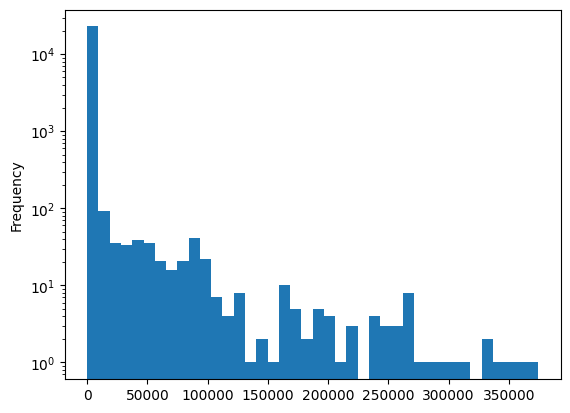

In [24]:
from analytics.metrics.time import TimeMetrics

# Out of curisosity, how far apart are events in this dataset (in seconds)?
diffs = TimeMetrics.get_all_diffs(data_subset, timestamp_col, grouping_cols)
diffs.DeltaSeconds[diffs.DeltaSeconds > 0].plot.hist(bins=40, log=True)

In [25]:
# Determine a gap to be considered idle time or taking a break based
# on the type of dataset. Can confirm with the histogram above if it makes sense
idle_gap = None
break_gap = None
if config.granularity == Granularity.Submission:
    idle_gap = 5 * 60  # 5 minutes
    break_gap = 30 * 60  # 30 minutes
elif config.granularity == Granularity.Edit or config.granularity == Granularity.Keystroke:
    idle_gap = 30
    break_gap = 3 * 60 # 3 minutes
else:
    raise NotImplementedError(f"{config.granularity} granularity has not been determined.")


In [26]:
from analytics.metrics.time import TimeMetrics
time_metrics = TimeMetrics(idle_gap, break_gap, True, timestamp_col)

time_results = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))
time_results

C:\Users\twprice\AppData\Local\Temp\ipykernel_28828\3940545762.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  time_results = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))


ActiveTime  \
SubjectID                        AssignmentID ProblemID               
00c54f9462673d4c09d2a88121860841 439.0        1                 0.0   
                                              3                 0.0   
                                              5                37.0   
                                              12                0.0   
                                              13              421.0   
...                                                             ...   
ffb72475a81de0e95b910ffad039f5c2 439.0        232            1630.0   
                                              233             120.0   
                                              234              40.0   
                                              235            1065.0   
                                              236               0.0   

                                                         PassiveTime  \
SubjectID                        AssignmentID ProblemID                
00c54f9462673d4c09d2a88121860841 439.0        1                  0.0   
                                              3                  0.0   
                                              5                  0.0   
                                              12                 0.0   
                                              13                 0.0   
...                                                              ...   
ffb72475a81de0e95b910ffad039f5c2 439.0        232              571.0   
                                              233                0.0   
                                              234                0.0   
                                              235                0.0   
                                              236                0.0   

                                                         TotalTime  \
SubjectID                        AssignmentID ProblemID              
00c54f9462673d4c09d2a88121860841 439.0        1                0.0   
                                              3                0.0   
                                              5               37.0   
                                              12               0.0   
                                              13             421.0   
...                                                            ...   
ffb72475a81de0e95b910ffad039f5c2 439.0        232           2201.0   
                                              233            120.0   
                                              234             40.0   
                                              235           1065.0   
                                              236              0.0   

                                                         ActiveTimeAfterCorrect  \
SubjectID                        AssignmentID ProblemID                           
00c54f9462673d4c09d2a88121860841 439.0        1                             0.0   
                                              3                             0.0   
                                              5                             0.0   
                                              12                           31.0   
                                              13                            0.0   
...                                                                         ...   
ffb72475a81de0e95b910ffad039f5c2 439.0        232                           0.0   
                                              233                           0.0   
                                              234                           0.0   
                                              235                           0.0   
                                              236                           0.0   

                                                         #Breaks  \
SubjectID                        AssignmentID ProblemID            
00c54f9462673d4c09d2a88121860841 439.0        1                0   
 

In [27]:
time_results.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
count,6859.000000,6859.000000,6859.000000,6859.000000,6859.000000,6859,6479,6859
mean,160.628809,97.085289,257.714098,4.661612,0.104534,2019-03-01 11:38:03.775477760,2019-03-01 09:39:10.098471936,2019-03-01 13:06:18.033095168
min,0.000000,0.000000,0.000000,0.000000,0.000000,2019-02-20 17:40:39,2019-02-20 21:17:01,2019-02-20 21:17:01
25%,0.000000,0.000000,0.000000,0.000000,0.000000,2019-02-24 20:35:45,2019-02-24 20:32:23.500000,2019-02-24 20:56:43.500000
50%,33.000000,0.000000,36.000000,0.000000,0.000000,2019-02-25 04:05:33,2019-02-25 03:55:47,2019-02-25 04:15:56
75%,181.500000,0.000000,227.000000,0.000000,0.000000,2019-03-07 05:29:36.500000,2019-03-07 04:49:30,2019-03-07 16:57:48.500000
max,5455.000000,5100.000000,8353.000000,2752.000000,7.000000,2019-03-09 04:58:46,2019-03-09 04:58:47,2019-03-09 04:58:59
std,325.835024,357.315763,581.078054,47.893497,0.398680,NaN,NaN,NaN


In [28]:
time_results.corr(method="spearman")

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
ActiveTime,1.000000,0.361758,0.960527,0.070177,0.333784,0.001079,-0.073257,0.029502
PassiveTime,0.361758,1.000000,0.531813,0.071606,0.316878,0.042037,-0.006719,0.070343
TotalTime,0.960527,0.531813,1.000000,0.075985,0.346215,0.010385,-0.064922,0.039835
ActiveTimeAfterCorrect,0.070177,0.071606,0.075985,1.000000,0.042829,0.000132,0.033387,0.011987
#Breaks,0.333784,0.316878,0.346215,0.042829,1.000000,0.049304,0.025832,0.118590
StartTime,0.001079,0.042037,0.010385,0.000132,0.049304,1.000000,0.839751,0.993101
FirstCorrectTime,-0.073257,-0.006719,-0.064922,0.033387,0.025832,0.839751,1.000000,0.837403
EndTime,0.029502,0.070343,0.039835,0.011987,0.118590,0.993101,0.837403,1.000000


In [29]:
from analytics.metrics.score import SubmissionScoreMetrics
from spec.enums import EventType

score_metrics = SubmissionScoreMetrics(config.submit_event)

subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


C:\Users\twprice\AppData\Local\Temp\ipykernel_28828\2954975142.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


In [30]:
subject_problem_score.head()

Attempts  \
SubjectID                        AssignmentID ProblemID             
00c54f9462673d4c09d2a88121860841 439.0        1                 1   
                                              3                 1   
                                              5                 2   
                                              12                1   
                                              13                5   

                                                         FirstCorrect  \
SubjectID                        AssignmentID ProblemID                 
00c54f9462673d4c09d2a88121860841 439.0        1                  True   
                                              3                  True   
                                              5                 False   
                                              12                 True   
                                              13                False   

                                                         EverCorrect  \
SubjectID                        AssignmentID ProblemID                
00c54f9462673d4c09d2a88121860841 439.0        1                 True   
                                              3                 True   
                                              5                 True   
                                              12                True   
                                              13                True   

                                                         Attempted  MaxScore  \
SubjectID                        AssignmentID ProblemID                        
00c54f9462673d4c09d2a88121860841 439.0        1               True       1.0   
                                              3               True       1.0   
                                              5               True       1.0   
                                              12              True       1.0   
                                              13              True       1.0   

                                                         MinScore  MeanScore  \
SubjectID                        AssignmentID ProblemID                        
00c54f9462673d4c09d2a88121860841 439.0        1              1.00      1.000   
                                              3              1.00      1.000   
                                              5              0.75      0.875   
                                              12             1.00      1.000   
                                              13             0.00      0.200   

                                                         TotalAttempts  
SubjectID                        AssignmentID ProblemID                 
00c54f9462673d4c09d2a88121860841 439.0        1                      1  
                                              3                      1  
                                              5                      2  
                                              12                     2  
                                              13                     5

In [31]:
subject_problem_score.describe()

,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts
count,6859.000000,6859.000000,6859.000000,6859.000000,6859.000000
mean,4.324974,0.977825,0.449785,0.659819,4.445692
std,6.241619,0.120973,0.477079,0.322367,6.411914
min,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,0.000000,0.366667,1.000000
50%,2.000000,1.000000,0.000000,0.640000,2.000000
75%,5.000000,1.000000,1.000000,1.000000,5.000000
max,93.000000,1.000000,1.000000,1.000000,93.000000


In [32]:
all_features = pd.merge(
    time_results.reset_index(),
    subject_problem_score.reset_index(),
    on=grouping_cols,
    how="outer"
)
if error_results is not None:
    all_features = pd.merge(
        all_features,
        error_results.reset_index(),
        on=grouping_cols,
        how="outer"
    )
all_features.head()

,SubjectID,AssignmentID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,...,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
0,00c54f9462673d4c09d2a88121860841,439.0,1,0.0,0.0,0.0,0.0,0,2019-02-24 05:13:03,2019-02-24 05:13:03,...,True,True,True,1.0,1.00,1.000,1,0.000000,0.0,0.0
1,00c54f9462673d4c09d2a88121860841,439.0,3,0.0,0.0,0.0,0.0,0,2019-02-24 05:13:33,2019-02-24 05:13:33,...,True,True,True,1.0,1.00,1.000,1,0.000000,0.0,0.0
2,00c54f9462673d4c09d2a88121860841,439.0,5,37.0,0.0,37.0,0.0,0,2019-02-24 05:09:54,2019-02-24 05:10:31,...,False,True,True,1.0,0.75,0.875,2,0.000000,0.0,0.0
3,00c54f9462673d4c09d2a88121860841,439.0,12,0.0,0.0,0.0,31.0,0,2019-02-24 05:14:37,2019-02-24 05:14:37,...,True,True,True,1.0,1.00,1.000,2,0.000000,0.0,0.0
4,00c54f9462673d4c09d2a88121860841,439.0,13,421.0,0.0,421.0,0.0,0,2019-02-24 04:27:49,2019-02-24 04:34:50,...,False,True,True,1.0,0.00,0.200,5,0.545455,0.0,4.0


In [33]:
# Some features are NA for some students, e.g. because
# they never got a problem right (no FirstCorrectTime) or
# because they only compiled once and errors metrics are undefined.
all_features.isna().mean()

SubjectID                 0.000000
AssignmentID              0.000000
ProblemID                 0.000000
ActiveTime                0.000000
PassiveTime               0.000000
TotalTime                 0.000000
ActiveTimeAfterCorrect    0.000000
#Breaks                   0.000000
StartTime                 0.000000
FirstCorrectTime          0.055402
EndTime                   0.000000
Attempts                  0.000000
FirstCorrect              0.000000
EverCorrect               0.000000
Attempted                 0.000000
MaxScore                  0.000000
MinScore                  0.000000
MeanScore                 0.000000
TotalAttempts             0.000000
ErrorQuotient             0.001750
RepeatedErrorDensity      0.001750
FailedCompileCount        0.000000
dtype: float64

In [34]:
median_features = all_features.groupby(problem_id_col)[[TimeMetrics.ACTIVE_TIME, SubmissionScoreMetrics.MAX_SCORE]].median()
all_features_with_median = all_features.merge(
    median_features,
    on=problem_id_col,
    suffixes=("", "_median"),
    how="left"
)

# We can calculate a few custom metrics
all_features["AtLeatMedianActiveTime"] = (all_features[TimeMetrics.ACTIVE_TIME] >= all_features_with_median[TimeMetrics.ACTIVE_TIME + "_median"]) + 0
all_features["AtLeatMedianMaxScore"] = (all_features[SubmissionScoreMetrics.MAX_SCORE] >= all_features_with_median[SubmissionScoreMetrics.MAX_SCORE + "_median"]) + 0
all_features["HadEffort"] = all_features["AtLeatMedianActiveTime"] | all_features["AtLeatMedianMaxScore"]
all_features.describe()

,AssignmentID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
count,6859.000000,6859.000000,6859.000000,6859.000000,6859.000000,6859.000000,6859.000000,6859,6479,6859,...,6859.000000,6859.000000,6859.000000,6859.000000,6847.000000,6847.000000,6859.000000,6859.000000,6859.000000,6859.000000
mean,461.204986,86.115906,160.628809,97.085289,257.714098,4.661612,0.104534,2019-03-01 11:38:03.775477760,2019-03-01 09:39:10.098471936,2019-03-01 13:06:18.033095168,...,0.977825,0.449785,0.659819,4.445692,0.131724,0.420678,1.982359,0.600233,0.944598,0.985421
min,439.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2019-02-20 17:40:39,2019-02-20 21:17:01,2019-02-20 21:17:01,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,439.000000,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2019-02-24 20:35:45,2019-02-24 20:32:23.500000,2019-02-24 20:56:43.500000,...,1.000000,0.000000,0.366667,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,439.000000,25.000000,33.000000,0.000000,36.000000,0.000000,0.000000,2019-02-25 04:05:33,2019-02-25 03:55:47,2019-02-25 04:15:56,...,1.000000,0.000000,0.640000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
75%,487.000000,232.000000,181.500000,0.000000,227.000000,0.000000,0.000000,2019-03-07 05:29:36.500000,2019-03-07 04:49:30,2019-03-07 16:57:48.500000,...,1.000000,1.000000,1.000000,5.000000,0.200000,0.000000,2.000000,1.000000,1.000000,1.000000
max,487.000000,236.000000,5455.000000,5100.000000,8353.000000,2752.000000,7.000000,2019-03-09 04:58:46,2019-03-09 04:58:47,2019-03-09 04:58:59,...,1.000000,1.000000,1.000000,93.000000,1.000000,37.025641,60.000000,1.000000,1.000000,1.000000
std,23.934524,94.448082,325.835024,357.315763,581.078054,47.893497,0.398680,NaN,NaN,NaN,...,0.120973,0.477079,0.322367,6.411914,0.233675,1.586132,4.050909,0.489886,0.228779,0.119870


In [35]:
# Let's take the z-score per problem for each numeric feature to
# normalize the features before combining across problems.
all_features_z = all_features.copy()

time_cols = [
    TimeMetrics.START_TIME,
    TimeMetrics.FIRST_CORRECT_TIME,
    TimeMetrics.END_TIME,
]

all_features_z[time_cols] = all_features_z[time_cols].astype('int64') / 1e9
numeric_cols = all_features_z.select_dtypes(include=["number"]).columns
# remove the grouping columns from numeric_cols
numeric_cols = numeric_cols.difference(grouping_cols)
all_features_z[numeric_cols] = all_features_z.groupby(problem_id_col)[numeric_cols].transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))


In [36]:
all_features_z.head()

,SubjectID,AssignmentID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
0,00c54f9462673d4c09d2a88121860841,439.0,1,-0.320032,-0.183395,-0.279133,-0.153571,-0.122885,-0.232040,0.105101,...,0.099822,0.902253,0.856028,-0.395157,-0.379270,-0.139009,-0.302412,0.000000,0.105119,0.000000
1,00c54f9462673d4c09d2a88121860841,439.0,3,-0.567499,-0.224637,-0.475306,-0.151418,-0.170532,-0.239052,0.247447,...,0.190071,1.032926,0.961486,-0.603868,-0.447614,-0.279166,-0.490601,-1.001376,0.247456,0.091161
2,00c54f9462673d4c09d2a88121860841,439.0,5,-0.371044,-0.217973,-0.367808,-0.122057,-0.149491,-0.212657,0.213813,...,0.163030,0.414428,0.436964,-0.353446,-0.462486,-0.279530,-0.533034,0.995897,0.213822,0.000000
3,00c54f9462673d4c09d2a88121860841,439.0,12,-0.271119,-0.116482,-0.221842,2.332309,-0.087815,-0.237400,0.118165,...,0.111464,0.715804,0.687421,-0.038185,-0.343607,-0.127343,-0.245570,0.000000,0.118182,0.000000
4,00c54f9462673d4c09d2a88121860841,439.0,13,0.131324,-0.443366,-0.227098,-0.182854,-0.460855,-0.040223,0.295119,...,0.206647,-0.507137,-0.641400,-0.392472,0.536671,-0.463884,-0.275556,0.993543,0.295123,0.145290


In [54]:
merge_cols = grouping_cols.copy()
merge_cols.remove(Cols.ProblemID)
merge_cols.remove(Cols.AssignmentID)
merge_cols = [col for col in merge_cols if col in all_features_z.columns]

# Take the average across all problems for each student
subject_means = all_features_z.drop([Cols.ProblemID, Cols.AssignmentID], axis=1).groupby(merge_cols).mean()

# Sometimes there are no non-NA values for a student across all problems for a given
# feature and we need to deal with that.

# For EQ and RED having no attempts with a successful compile (and therefore a score)
# should give you the max (worst) value
for col in [ErrorMetrics.ERROR_QUOTIENT, ErrorMetrics.REPEATED_ERROR_DENSITY]:
    max_val = subject_means[col].max()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(max_val)

# But for score metrics, not trying a problem should lead to the minimum value
for col in [SubmissionScoreMetrics.MAX_SCORE, SubmissionScoreMetrics.MEAN_SCORE, SubmissionScoreMetrics.MIN_SCORE]:
    min_val = subject_means[col].min()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(min_val)

subject_means.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
SubjectID,,,,,,,,,,,,,,,,,,,,,
00c54f9462673d4c09d2a88121860841,-0.439320,-0.181586,-0.369276,-0.011134,-0.249826,0.494663,0.225859,0.457451,-0.494267,0.750000,...,0.177106,0.760289,0.756211,-0.494658,-0.459537,-0.299441,-0.487337,-0.402311,0.225828,0.095701
033ee034918011e4e34a7f97d464261f,-0.333431,-0.303236,-0.379835,-0.136213,-0.318750,-1.254953,-1.260696,-1.363972,-0.283869,0.250000,...,-0.283394,0.109233,0.164246,-0.300815,-0.406862,-0.260078,-0.416014,0.162679,-1.260642,-1.321958
036ad3e516c5bf3a4b3be35b137bcbb8,1.015806,0.128167,0.658912,0.796303,1.328017,-0.531050,0.225800,-0.330155,1.253774,0.100000,...,0.177106,-0.764485,-0.939535,1.480943,0.887925,1.825493,1.903009,0.596191,0.225828,0.095701
04c32d4d95425f73b3a1d6502aed4d48,0.393640,0.020536,0.234908,-0.105187,-0.195517,-0.172627,0.225820,-0.215230,0.374854,0.250000,...,0.177106,-0.111167,-0.096668,0.349112,0.188573,0.305805,0.454678,0.396487,0.225828,0.095701
0503bf609757acf2e75aa8cbc0d8323b,0.064867,-0.240011,-0.119561,-0.138216,-0.200805,0.547502,0.197106,0.526162,-0.043785,0.181818,...,0.149361,-0.316196,0.078451,-0.064653,-0.453094,-0.294034,-0.242418,0.269349,0.197079,0.078072


In [56]:
# We can also take the sum of features across problems, which treats
# missing problems differently than the mean.
subject_totals = all_features_z.drop([Cols.ProblemID, Cols.AssignmentID], axis=1).groupby(merge_cols).sum()
subject_totals.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
SubjectID,,,,,,,,,,,,,,,,,,,,,
00c54f9462673d4c09d2a88121860841,-8.786407,-3.631721,-7.385518,-0.222677,-4.996519,9.893265,4.517181,9.149029,-9.885349,15,...,3.542115,15.205776,15.124229,-9.893158,-9.190742,-5.988825,-9.746742,-8.046227,4.516566,1.914017
033ee034918011e4e34a7f97d464261f,-4.001169,-3.638834,-4.558023,-1.634560,-3.825000,-15.059434,-15.128352,-16.367660,-3.406423,3,...,-3.400723,1.310794,1.970950,-3.609777,-4.882340,-3.120935,-4.992169,1.952152,-15.127705,-15.863499
036ad3e516c5bf3a4b3be35b137bcbb8,20.316124,2.563341,13.178244,15.926069,26.560344,-10.621001,4.516000,-6.603107,25.075481,2,...,3.542115,-15.289702,-18.790708,29.618864,17.758501,36.509858,38.060183,11.923810,4.516566,1.914017
04c32d4d95425f73b3a1d6502aed4d48,7.872798,0.410725,4.698157,-2.103742,-3.910350,-3.452535,4.516392,-4.304606,7.497076,5,...,3.542115,-2.223348,-1.933367,6.982233,3.771460,6.116100,9.093563,7.929748,4.516566,1.914017
0503bf609757acf2e75aa8cbc0d8323b,0.713532,-2.640124,-1.315168,-1.520373,-2.208856,6.022523,2.168161,5.787787,-0.481640,2,...,1.642976,-3.478153,0.862959,-0.711186,-4.984038,-3.234373,-2.666596,2.962834,2.167869,0.858796


In [57]:
# Lets merge the means and totals into a single DataFrame
subject_features = pd.merge(
    subject_means.reset_index(),
    subject_totals.reset_index(),
    on=merge_cols,
    how="outer",
    suffixes=('_mean', '_sum')
)
subject_features.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,00c54f9462673d4c09d2a88121860841,-0.439320,-0.181586,-0.369276,-0.011134,-0.249826,0.494663,0.225859,0.457451,-0.494267,...,3.542115,15.205776,15.124229,-9.893158,-9.190742,-5.988825,-9.746742,-8.046227,4.516566,1.914017
1,033ee034918011e4e34a7f97d464261f,-0.333431,-0.303236,-0.379835,-0.136213,-0.318750,-1.254953,-1.260696,-1.363972,-0.283869,...,-3.400723,1.310794,1.970950,-3.609777,-4.882340,-3.120935,-4.992169,1.952152,-15.127705,-15.863499
2,036ad3e516c5bf3a4b3be35b137bcbb8,1.015806,0.128167,0.658912,0.796303,1.328017,-0.531050,0.225800,-0.330155,1.253774,...,3.542115,-15.289702,-18.790708,29.618864,17.758501,36.509858,38.060183,11.923810,4.516566,1.914017
3,04c32d4d95425f73b3a1d6502aed4d48,0.393640,0.020536,0.234908,-0.105187,-0.195517,-0.172627,0.225820,-0.215230,0.374854,...,3.542115,-2.223348,-1.933367,6.982233,3.771460,6.116100,9.093563,7.929748,4.516566,1.914017
4,0503bf609757acf2e75aa8cbc0d8323b,0.064867,-0.240011,-0.119561,-0.138216,-0.200805,0.547502,0.197106,0.526162,-0.043785,...,1.642976,-3.478153,0.862959,-0.711186,-4.984038,-3.234373,-2.666596,2.962834,2.167869,0.858796


In [58]:
subject_features.isna().mean()[subject_features.isna().mean() != 0]

Series([], dtype: float64)

In [59]:
# No feature should be NA at this point
assert subject_features.isna().mean().mean() == 0

In [60]:
# Take one last z-score across all students for each numeric feature
# This makes means and sums more comparable across students
subject_feautres_z = subject_features.copy()
numeric_cols = subject_feautres_z.select_dtypes(include=["number"]).columns
numeric_cols = numeric_cols.difference(merge_cols)
subject_feautres_z[numeric_cols] = subject_feautres_z[numeric_cols].apply(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1), axis=0)
subject_feautres_z.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,00c54f9462673d4c09d2a88121860841,-0.870061,-0.479168,-0.800249,-0.015062,-0.546516,0.551992,0.428790,0.505918,-0.931539,...,0.457681,1.833732,1.804722,-1.130746,-1.377794,-0.931933,-1.194888,-1.157523,0.564330,0.447838
1,033ee034918011e4e34a7f97d464261f,-0.669924,-0.777989,-0.821943,-0.309527,-0.692948,-1.605898,-1.413141,-1.746801,-0.550983,...,-0.439411,0.158074,0.235187,-0.412582,-0.731917,-0.485655,-0.612008,0.280835,-1.890158,-3.711713
2,036ad3e516c5bf3a4b3be35b137bcbb8,1.880211,0.281708,1.312180,1.885827,2.805662,-0.713072,0.428717,-0.468187,2.230205,...,0.457681,-1.843853,-2.242230,3.385310,2.662196,5.681370,4.665932,1.715348,0.564330,0.447838
3,04c32d4d95425f73b3a1d6502aed4d48,0.704281,0.017324,0.441056,-0.236485,-0.431136,-0.271010,0.428741,-0.326049,0.640471,...,0.457681,-0.268123,-0.230702,0.798039,0.565383,0.951738,1.114812,1.140766,0.564330,0.447838
4,0503bf609757acf2e75aa8cbc0d8323b,0.082881,-0.622683,-0.287205,-0.314242,-0.442370,0.617161,0.393163,0.590899,-0.116737,...,0.212291,-0.419446,0.102974,-0.081285,-0.747162,-0.503307,-0.326907,0.426231,0.270868,0.200939


In [79]:
# Get the grades to compare features to
grades = dataset.get_link_table(config.grades_link_table_name)
grades.head()

,SubjectID,X-Grade
0,65be44ae7088566069cc3bef454174a7,0.3600
1,0bdf2c1f053650715e1f0c725d754b96,0.3917
2,ff12b08dbcd163de643a3f597b14c6e4,0.0000
3,ad8d3a0a0f0a084a97fad357c649438c,0.6160
4,f4db8537e9d75da46c4efc36a2d70956,0.4310


In [83]:
grades.rename(columns={
    config.final_grade_column: "Grade",
    # Edwards 2019 calls it Group
    # "Group": Cols.CourseSectionID,
    },
inplace=True)

# Drop 0 grades, since they're likely students who skipped the test
print(f"Dropping {grades[grades['Grade'] <= 0].shape[0]} rows with 0 grades")
grades = grades[grades["Grade"] > 0]

Dropping 32 rows with 0 grades


In [84]:
grade_merge_cols = [col for col in merge_cols if col in grades.columns]
print(f"Merging on columns: {grade_merge_cols}")

subject_feautres_labeled = pd.merge(
    subject_feautres_z,
    grades[grade_merge_cols + ["Grade"]],
    on=grade_merge_cols,
    how="inner",
)

Merging on columns: [<MainTableColumns.SubjectID: 'SubjectID'>]


In [85]:
print(subject_features.shape)
subject_feautres_labeled.head()

(406, 45)


,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum,Grade
0,036ad3e516c5bf3a4b3be35b137bcbb8,1.880211,0.281708,1.312180,1.885827,2.805662,-0.713072,0.428717,-0.468187,2.230205,...,-1.843853,-2.242230,3.385310,2.662196,5.681370,4.665932,1.715348,0.564330,0.447838,0.7720
1,04c32d4d95425f73b3a1d6502aed4d48,0.704281,0.017324,0.441056,-0.236485,-0.431136,-0.271010,0.428741,-0.326049,0.640471,...,-0.268123,-0.230702,0.798039,0.565383,0.951738,1.114812,1.140766,0.564330,0.447838,0.7060
2,0503bf609757acf2e75aa8cbc0d8323b,0.082881,-0.622683,-0.287205,-0.314242,-0.442370,0.617161,0.393163,0.590899,-0.116737,...,-0.419446,0.102974,-0.081285,-0.747162,-0.503307,-0.326907,0.426231,0.270868,0.200939,0.7617
3,06d801cb636235b298c40029ad9921e7,4.269587,2.047984,3.722936,1.971911,0.225056,0.785343,0.384212,0.781084,3.688004,...,-0.621497,-0.782379,2.330220,0.867495,2.972649,1.742868,0.858521,0.237209,0.172354,0.8800
4,07ae4cca3f90a49347ccb5c1a82ff46f,-0.583938,-0.673407,-0.733238,-0.294461,-0.546516,1.032544,0.282105,0.997767,-0.492546,...,1.205302,1.043463,-0.583156,-0.680111,-0.520503,-0.658791,-0.870139,0.268453,-0.291487,0.8400


In [86]:
subject_feautres_labeled.groupby(grade_merge_cols).Grade.count().describe()

count    341.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: Grade, dtype: float64

In [87]:
assert subject_feautres_labeled.groupby(grade_merge_cols).Grade.count().max() == 1

In [88]:

out_dir = os.path.join("..", "..", "analysis", "features")
print(len(subject_feautres_labeled))
if not os.path.exists(out_dir):
    os.makedirs(out_dir)
subject_feautres_labeled.to_csv(os.path.join(out_dir, f"{config.name}.csv"), index=False)

341
